Filename: C:\Users\HP\.astropy\cache\download\url\5c4c2abaefb079d370f9a22ef360e989\contents
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     596   (1024, 1024, 1, 1)   float32   


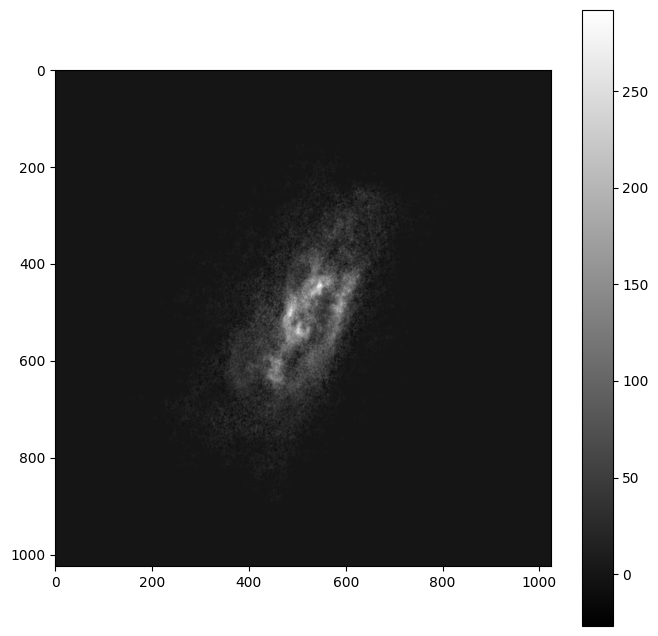

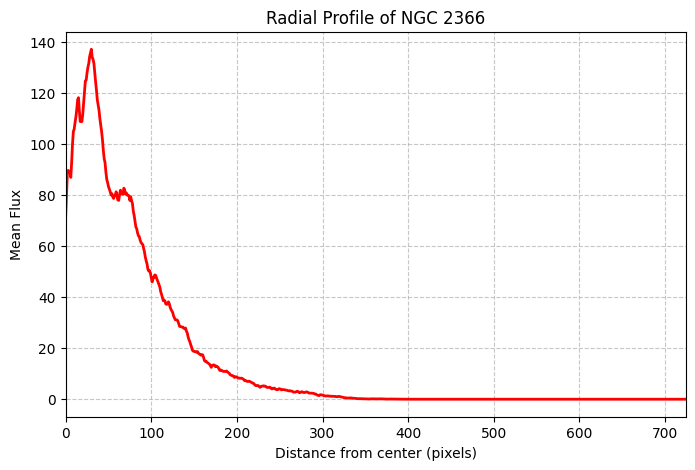

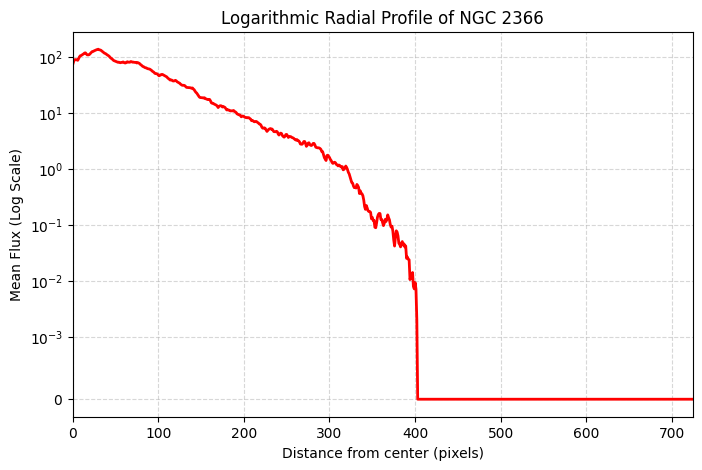

In [ ]:
import numpy as np

# Set up matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as colors

%matplotlib inline

from astropy.io import fits

from astropy.utils.data import download_file

image_file = download_file(
    "https://things.cv.nrao.edu/littlethings/ngc2366/HI/NGC2366_R_X0_P_R.FITS", cache=True
)

hdu_list = fits.open(image_file)
hdu_list.info()

image_data = hdu_list[0].data

image_data_2d = np.squeeze(image_data)


# plot the image
plt.figure(figsize=(8, 8))
plt.imshow(image_data_2d, cmap="gray")
plt.colorbar()


###########AI-Generated###############

# Create the Radial Profile
y_len, x_len = image_data_2d.shape

center_y, center_x = y_len // 2, x_len // 2

y_indices, x_indices = np.indices((y_len, x_len))

radii = np.sqrt((x_indices - center_x)**2 + (y_indices - center_y)**2)

radii_int = radii.astype(int)

radii_flat = radii_int.flatten()
data_flat = image_data_2d.flatten()

valid_mask = ~np.isnan(data_flat)
radii_valid = radii_flat[valid_mask]
data_valid = data_flat[valid_mask]

bin_sums = np.bincount(radii_valid, weights=data_valid)
bin_counts = np.bincount(radii_valid)

bin_counts[bin_counts == 0] = 1

radial_profile = bin_sums / bin_counts

# Plot the Radial Profile
plt.figure(figsize=(8, 5))
plt.plot(radial_profile, color='red', linewidth=2)
plt.title('Radial Profile of NGC 2366')
plt.xlabel('Distance from center (pixels)')
plt.ylabel('Mean Flux')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlim(0, max(radii_valid)) 
plt.show()

#Plot the Log
plt.figure(figsize=(8, 5))
plt.plot(radial_profile, color='red', linewidth=2)
plt.yscale('symlog', linthresh=0.001) 
plt.title('Logarithmic Radial Profile of NGC 2366')
plt.xlabel('Distance from center (pixels)')
plt.ylabel('Mean Flux (Log Scale)')
plt.grid(True, which="both", linestyle='--', alpha=0.5) 
plt.xlim(0, max(radii_valid))
plt.show()